# Student Attendance Modeling (Regression + Classification)
This notebook uses a clean 1000-record dataset and trains multiple models for both tasks:
- Regression: predict `Attendance_Percentage`
- Classification: predict `Attendance_Label` (High/Low)


In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, f1_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [12]:
df = pd.read_csv('attendance.csv')
df.head()


,Student_ID,Math_Score,Science_Score,English_Score,Study_Hours_Per_Week,Assignments_Completed,Participation_Score,Absences,Previous_Attendance_Percentage,Attendance_Percentage,Attendance_Label
0,1,49,38,70,8,7,3,23,50.43,50.15,Low
1,2,89,39,38,3,6,4,16,76.91,57.89,Low
2,3,60,88,63,15,18,5,25,91.07,81.99,High
3,4,89,78,70,5,6,6,3,49.92,79.64,High
4,5,47,80,79,20,8,1,23,69.35,76.59,High


In [13]:
print('Shape:', df.shape)
df.info()


Shape: (1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      1000 non-null   int64  
 1   Math_Score                      1000 non-null   int64  
 2   Science_Score                   1000 non-null   int64  
 3   English_Score                   1000 non-null   int64  
 4   Study_Hours_Per_Week            1000 non-null   int64  
 5   Assignments_Completed           1000 non-null   int64  
 6   Participation_Score             1000 non-null   int64  
 7   Absences                        1000 non-null   int64  
 8   Previous_Attendance_Percentage  1000 non-null   float64
 9   Attendance_Percentage           1000 non-null   float64
 10  Attendance_Label                1000 non-null   object 
dtypes: float64(2), int64(8), object(1)
memory usage: 86.1+ KB


In [14]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Student_ID,1000.0,500.50000,288.819436,1.00,250.7500,500.500,750.2500,1000.0
Math_Score,1000.0,66.99900,18.959442,35.00,50.0000,67.000,83.0000,100.0
Science_Score,1000.0,67.86800,18.950401,35.00,50.0000,69.000,84.0000,100.0
English_Score,1000.0,68.55500,19.354989,35.00,52.0000,68.000,86.0000,100.0
Study_Hours_Per_Week,1000.0,13.14500,7.115519,1.00,7.0000,13.000,19.0000,25.0
Assignments_Completed,1000.0,10.30600,6.126328,0.00,5.0000,10.000,16.0000,20.0
Participation_Score,1000.0,5.51100,2.875439,1.00,3.0000,5.000,8.0000,10.0
Absences,1000.0,14.99100,8.960201,0.00,8.0000,15.000,23.0000,30.0
Previous_Attendance_Percentage,1000.0,71.67201,15.129195,45.25,58.2500,71.595,84.7325,98.0
Attendance_Percentage,1000.0,78.71560,13.872627,38.10,68.6725,79.215,90.1650,100.0


In [15]:
# Missing values check
df.isnull().sum()


Student_ID                        0
Math_Score                        0
Science_Score                     0
English_Score                     0
Study_Hours_Per_Week              0
Assignments_Completed             0
Participation_Score               0
Absences                          0
Previous_Attendance_Percentage    0
Attendance_Percentage             0
Attendance_Label                  0
dtype: int64

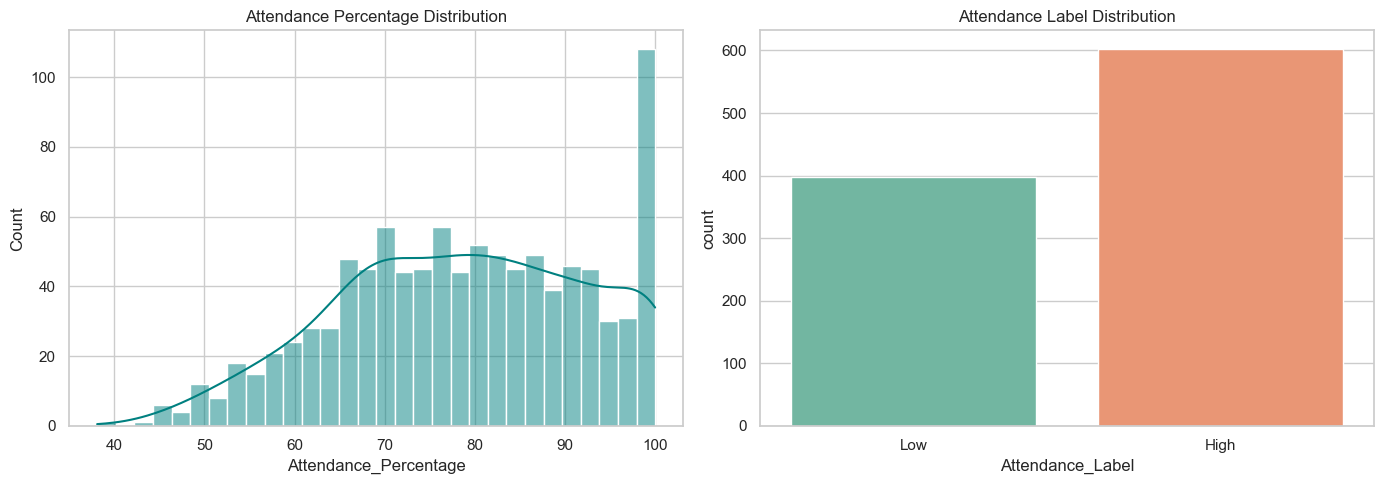

In [16]:
# Target distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Attendance_Percentage'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Attendance Percentage Distribution')

sns.countplot(data=df, x='Attendance_Label', ax=axes[1], palette='Set2')
axes[1].set_title('Attendance Label Distribution')

plt.tight_layout()
plt.show()


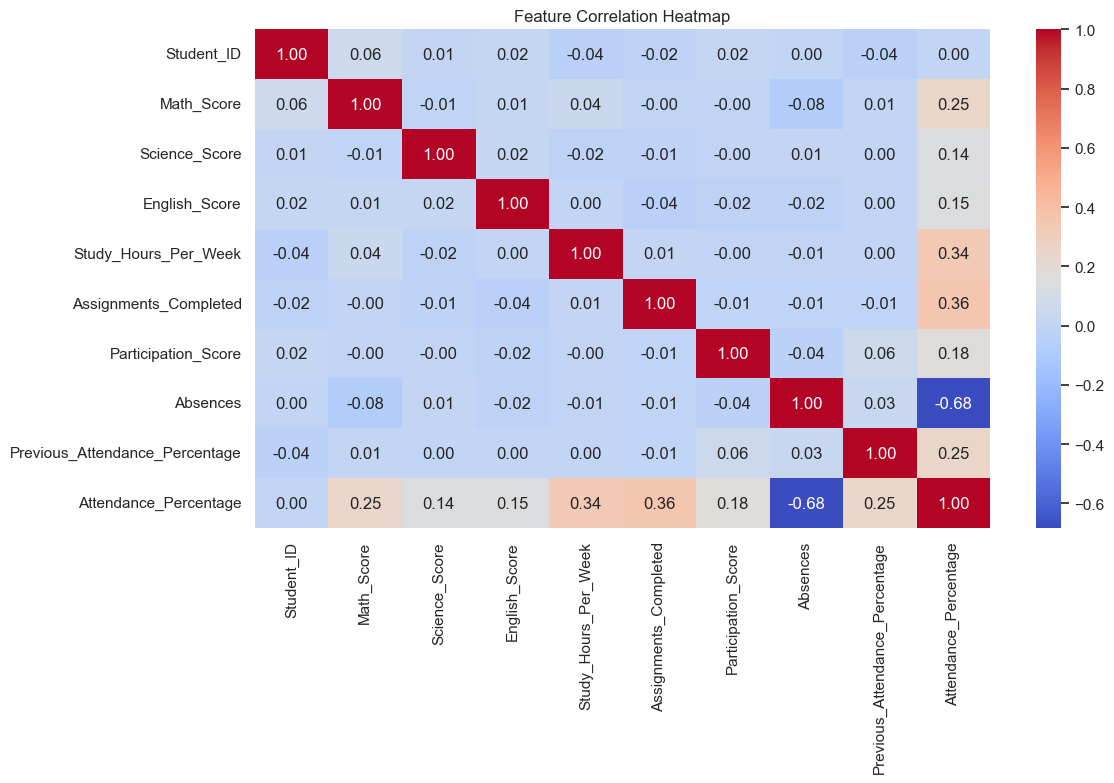

In [17]:
# Correlation heatmap
numeric_df = df.drop(columns=['Attendance_Label'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [18]:
feature_cols = [
    'Math_Score','Science_Score','English_Score','Study_Hours_Per_Week',
    'Assignments_Completed','Participation_Score','Absences','Previous_Attendance_Percentage'
]

X = df[feature_cols]
y_reg = df['Attendance_Percentage']
y_clf = df['Attendance_Label']


In [19]:
# Train/test split for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'KNNRegressor': KNeighborsRegressor(n_neighbors=7),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(C=10, epsilon=0.1, kernel='rbf'))
    ]),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=250, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

reg_results = []
reg_predictions = {}

for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    pred = model.predict(X_test_r)
    reg_predictions[name] = pred
    reg_results.append({
        'Model': name,
        'R2': r2_score(y_test_r, pred),
        'MAE': mean_absolute_error(y_test_r, pred),
        'RMSE': mean_squared_error(y_test_r, pred)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values(by='R2', ascending=False)
reg_results_df


,Model,R2,MAE,RMSE
0,LinearRegression,0.892428,3.835971,22.906380
2,Lasso,0.892427,3.835971,22.906550
1,Ridge,0.892427,3.835976,22.906571
4,SVR,0.881826,3.934974,25.163857
6,GradientBoostingRegressor,0.867437,4.190383,28.227994
5,RandomForestRegressor,0.822408,4.822208,37.816262
3,KNNRegressor,0.737966,6.095429,55.797335


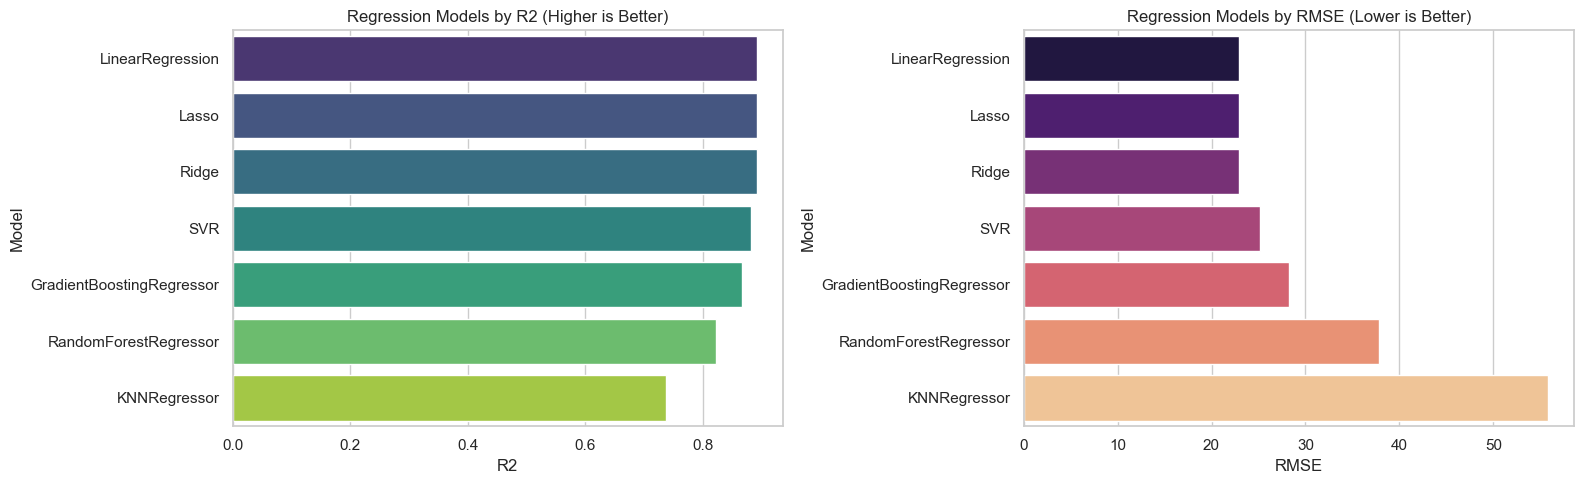

In [20]:
# Regression model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=reg_results_df, x='R2', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Regression Models by R2 (Higher is Better)')

sorted_rmse = reg_results_df.sort_values(by='RMSE', ascending=True)
sns.barplot(data=sorted_rmse, x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('Regression Models by RMSE (Lower is Better)')

plt.tight_layout()
plt.show()


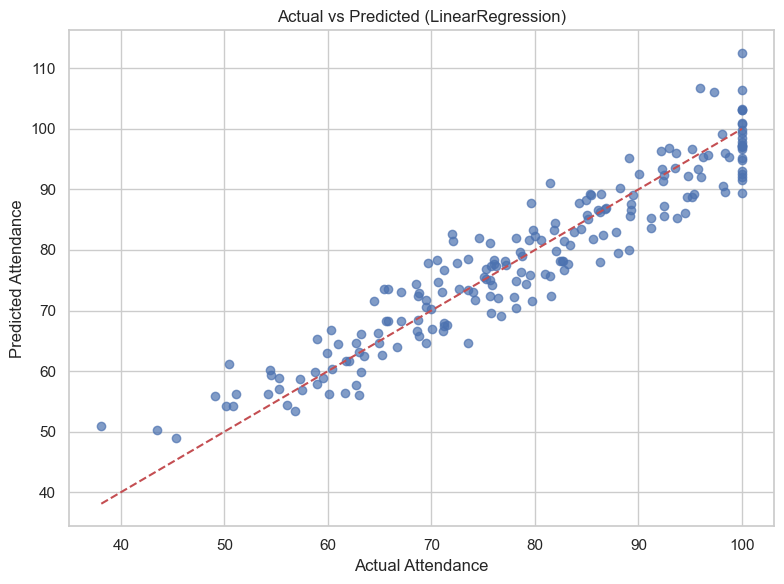

Best regression model: LinearRegression


In [21]:
# Actual vs predicted plot for best regression model
best_reg = reg_results_df.iloc[0]['Model']
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, reg_predictions[best_reg], alpha=0.7)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel('Actual Attendance')
plt.ylabel('Predicted Attendance')
plt.title(f'Actual vs Predicted ({best_reg})')
plt.tight_layout()
plt.show()

print('Best regression model:', best_reg)


In [22]:
# Train/test split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'KNNClassifier': KNeighborsClassifier(n_neighbors=7),
    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=3, gamma='scale', random_state=42))
    ]),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=250, random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42)
}

clf_results = []
clf_predictions = {}

for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    clf_predictions[name] = pred
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_c, pred),
        'F1_Macro': f1_score(y_test_c, pred, average='macro')
    })

clf_results_df = pd.DataFrame(clf_results).sort_values(by='Accuracy', ascending=False)
clf_results_df


,Model,Accuracy,F1_Macro
0,LogisticRegression,0.885,0.877002
3,RandomForestClassifier,0.885,0.877656
2,SVC,0.870,0.863388
4,GradientBoostingClassifier,0.865,0.856379
1,KNNClassifier,0.795,0.778229


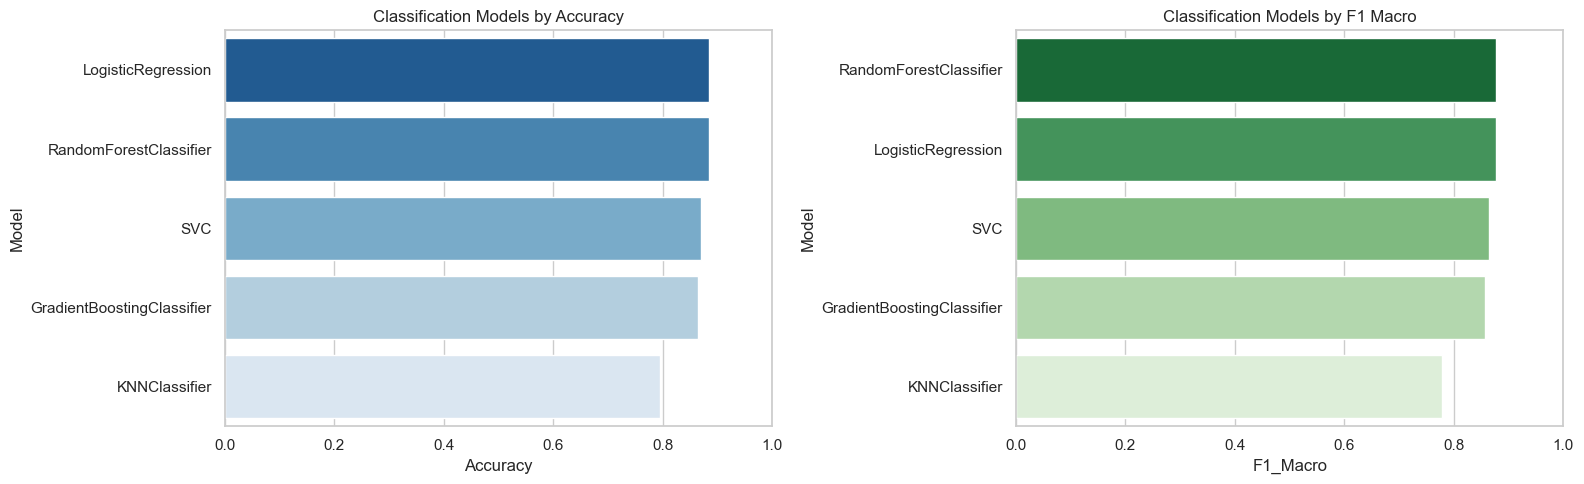

In [23]:
# Classification model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=clf_results_df, x='Accuracy', y='Model', ax=axes[0], palette='Blues_r')
axes[0].set_title('Classification Models by Accuracy')
axes[0].set_xlim(0, 1)

sorted_f1 = clf_results_df.sort_values(by='F1_Macro', ascending=False)
sns.barplot(data=sorted_f1, x='F1_Macro', y='Model', ax=axes[1], palette='Greens_r')
axes[1].set_title('Classification Models by F1 Macro')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


Best classification model: LogisticRegression
Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.95      0.91       120
         Low       0.91      0.79      0.85        80

    accuracy                           0.89       200
   macro avg       0.89      0.87      0.88       200
weighted avg       0.89      0.89      0.88       200



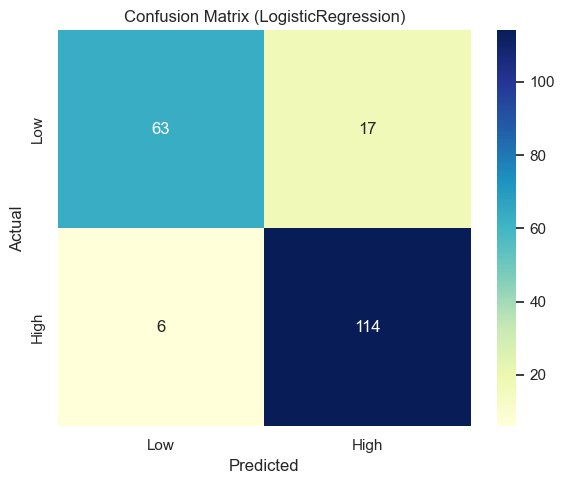

In [24]:
# Detailed report for best classification model
best_clf = clf_results_df.iloc[0]['Model']
best_pred = clf_predictions[best_clf]

print('Best classification model:', best_clf)
print('Classification Report:')
print(classification_report(y_test_c, best_pred))

cm = confusion_matrix(y_test_c, best_pred, labels=['Low', 'High'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title(f'Confusion Matrix ({best_clf})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [25]:
# Example prediction for a new student
sample_student = pd.DataFrame([{
    'Math_Score': 82,
    'Science_Score': 78,
    'English_Score': 85,
    'Study_Hours_Per_Week': 14,
    'Assignments_Completed': 17,
    'Participation_Score': 8,
    'Absences': 4,
    'Previous_Attendance_Percentage': 84.5
}])

# Re-fit best models on full training splits for a direct example
best_reg_model = reg_models[best_reg]
best_reg_model.fit(X_train_r, y_train_r)
reg_pred_value = best_reg_model.predict(sample_student)[0]

best_clf_model = clf_models[best_clf]
best_clf_model.fit(X_train_c, y_train_c)
clf_pred_value = best_clf_model.predict(sample_student)[0]

print('Predicted Attendance_Percentage:', round(float(reg_pred_value), 2))
print('Predicted Attendance_Label:', clf_pred_value)


Predicted Attendance_Percentage: 105.63
Predicted Attendance_Label: High
